In [1]:
import sys
from pathlib import Path

# Add project root so we can import from src/
project_root = Path.cwd().parent
sys.path.append(str(project_root))

import numpy as np
import tensorflow as tf

from src.preprocessing import load_dataset, load_test_dataset
from src.data_pipeline import build_pipelines

print(f"TensorFlow version: {tf.__version__}")
print(f"Project root:       {project_root}")

TensorFlow version: 2.21.0
Project root:       C:\Users\Josh\Documents\TrafficSignRecognition


In [2]:
GTSRB_ROOT = project_root / "data"
TRAIN_DIR  = GTSRB_ROOT / "Train"
TEST_CSV   = GTSRB_ROOT / "Test.csv"

USE_CLAHE = True
IMG_SIZE = 32

print("Loading training data (needed to recreate the same train/val split for context)...")
X_train, y_train = load_dataset(str(TRAIN_DIR), img_size=IMG_SIZE, use_clahe=USE_CLAHE)
print(f"Train: X={X_train.shape}, y={y_train.shape}")

print("Loading test data...")
X_test, y_test = load_test_dataset(str(TEST_CSV), str(GTSRB_ROOT), img_size=IMG_SIZE, use_clahe=USE_CLAHE)
print(f"Test:  X={X_test.shape}, y={y_test.shape}")

# Build pipelines (we'll only use test_ds and val_ds, but stratified split needs all)
train_ds, val_ds, test_ds = build_pipelines(X_train, y_train, X_test, y_test)
print(f"\ntest_ds batches: {tf.data.experimental.cardinality(test_ds).numpy()}")

Loading training data (needed to recreate the same train/val split for context)...
Train: X=(39209, 32, 32, 3), y=(39209,)
Loading test data...
Test:  X=(12630, 32, 32, 3), y=(12630,)

test_ds batches: 198


In [3]:
from src.models.vgg16_model import build_vgg16_model, compile_phase2 as vgg_compile_phase2
from src.models.resnet_model import build_resnet50_model, compile_phase2 as resnet_compile_phase2

MODELS_DIR = project_root / "src" / "models" / "saved"

print("Loading custom CNN (load_model — no Lambda)...")
cnn = tf.keras.models.load_model(MODELS_DIR / 'custom_cnn_best.keras')
print(f"  Params: {cnn.count_params():,}")

print("\nBuilding VGG16 architecture and loading weights...")
vgg = build_vgg16_model(freeze_base=False)
vgg = vgg_compile_phase2(vgg)
vgg.load_weights(MODELS_DIR / 'vgg16_phase2_best.keras')
print(f"  Params: {vgg.count_params():,}")

print("\nBuilding ResNet50 architecture and loading weights...")
resnet = build_resnet50_model(freeze_base=False)
resnet = resnet_compile_phase2(resnet)
resnet.load_weights(MODELS_DIR / 'resnet50_phase2_best.keras')
print(f"  Params: {resnet.count_params():,}")

models = {
    'custom_cnn': cnn,
    'vgg16': vgg,
    'resnet50': resnet,
}

print("\nAll three models loaded.")

Loading custom CNN (load_model — no Lambda)...
  Params: 294,347

Building VGG16 architecture and loading weights...

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
  Params: 14,736,747

Building ResNet50 architecture and loading weights...


C:\Users\Josh\Documents\TrafficSignRecognition\venv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
  Params: 23,675,819

All three models loaded.


C:\Users\Josh\Documents\TrafficSignRecognition\venv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 430 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [4]:
print("Re-evaluating on test set (verifying weights are intact)...\n")
test_results = {}

for name, model in models.items():
    print(f"Evaluating {name}...")
    loss, accuracy = model.evaluate(test_ds, verbose=0)
    test_results[name] = {'loss': loss, 'accuracy': accuracy}
    print(f"  loss={loss:.4f}  accuracy={accuracy:.4f}\n")

print("Expected (from Kaggle training):")
print("  custom_cnn:  ~0.9860")
print("  vgg16:       ~0.9905")
print("  resnet50:    ~0.9656")

Re-evaluating on test set (verifying weights are intact)...

Evaluating custom_cnn...
  loss=0.0533  accuracy=0.9885

Evaluating vgg16...
  loss=0.0447  accuracy=0.9918

Evaluating resnet50...
  loss=0.1509  accuracy=0.9615

Expected (from Kaggle training):
  custom_cnn:  ~0.9860
  vgg16:       ~0.9905
  resnet50:    ~0.9656


Saved figure to C:\Users\Josh\Documents\TrafficSignRecognition\report\figures\convergence_curves.png


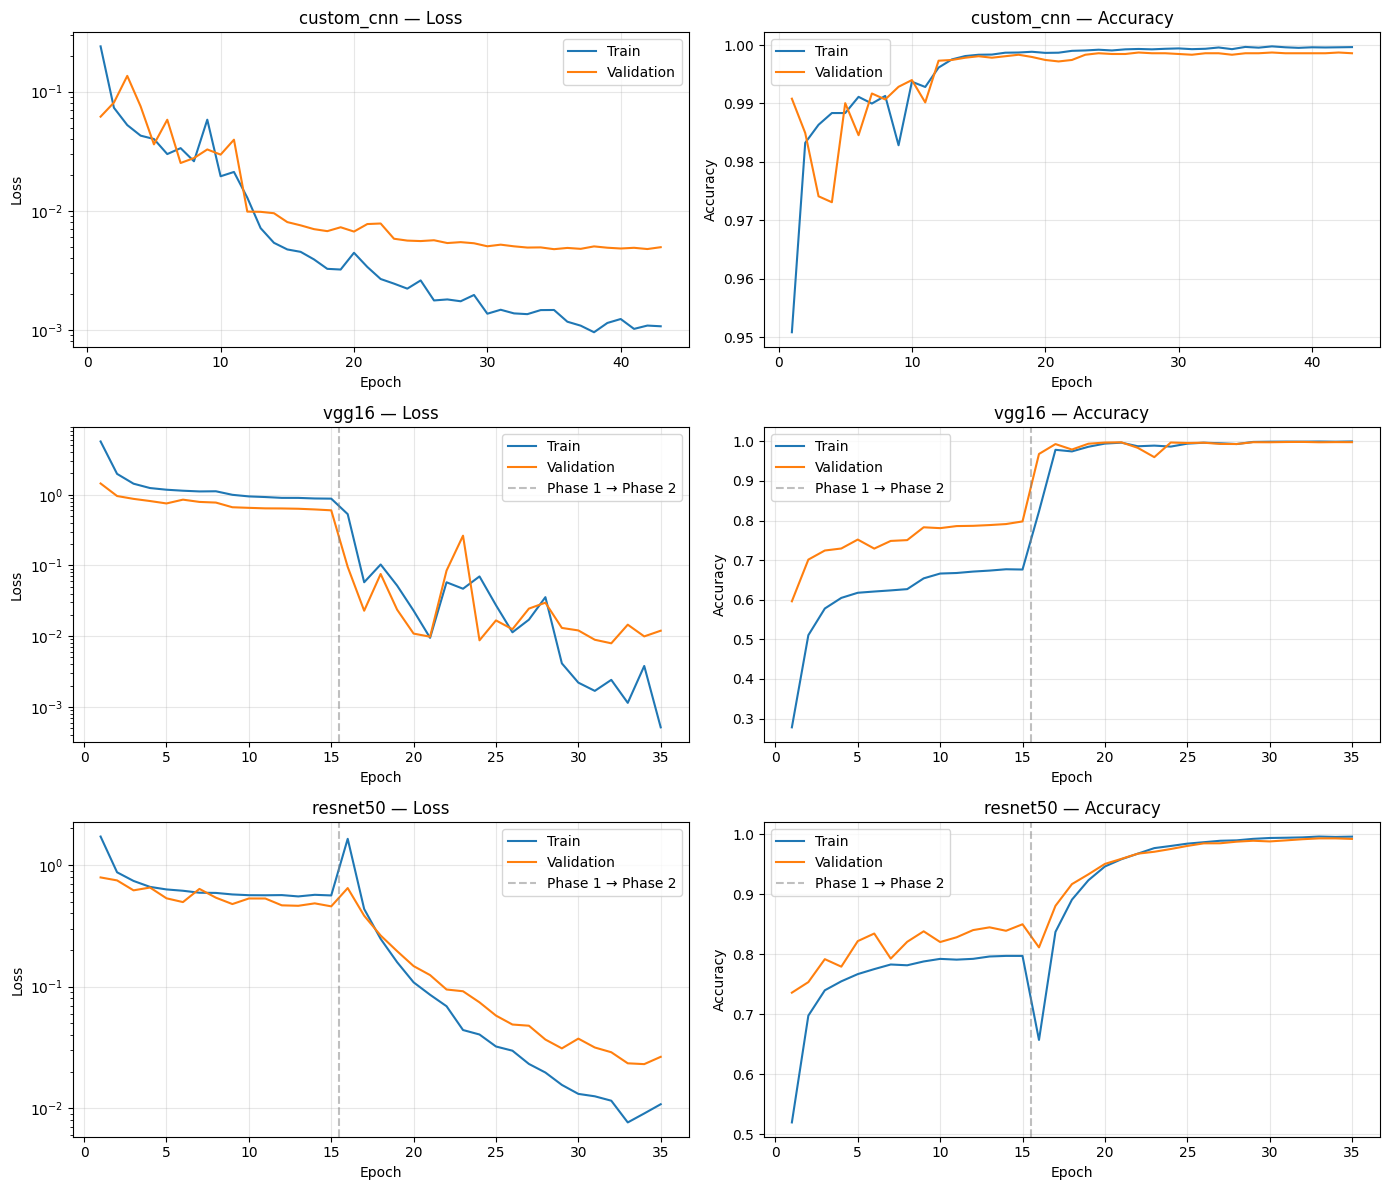

In [5]:
import json
import matplotlib.pyplot as plt

# Load all three histories
HISTORIES_DIR = project_root / "src" / "models" / "saved"

histories = {}
for name in ['custom_cnn', 'vgg16', 'resnet50']:
    path = HISTORIES_DIR / f'{name}_history.json'
    with open(path) as f:
        histories[name] = json.load(f)

# Helper to flatten phase1+phase2 histories into single lists
def get_curves(name):
    h = histories[name]
    if 'phase1' in h:
        # Two-phase model — concatenate
        train_loss = h['phase1']['loss'] + h['phase2']['loss']
        val_loss = h['phase1']['val_loss'] + h['phase2']['val_loss']
        train_acc = h['phase1']['accuracy'] + h['phase2']['accuracy']
        val_acc = h['phase1']['val_accuracy'] + h['phase2']['val_accuracy']
        phase_boundary = len(h['phase1']['loss'])
    else:
        train_loss = h['loss']
        val_loss = h['val_loss']
        train_acc = h['accuracy']
        val_acc = h['val_accuracy']
        phase_boundary = None
    return train_loss, val_loss, train_acc, val_acc, phase_boundary

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for row, name in enumerate(['custom_cnn', 'vgg16', 'resnet50']):
    train_loss, val_loss, train_acc, val_acc, phase_boundary = get_curves(name)
    epochs = range(1, len(train_loss) + 1)

    # Loss subplot
    ax = axes[row, 0]
    ax.plot(epochs, train_loss, label='Train', color='C0')
    ax.plot(epochs, val_loss, label='Validation', color='C1')
    if phase_boundary:
        ax.axvline(x=phase_boundary + 0.5, color='gray', linestyle='--',
                   alpha=0.5, label='Phase 1 → Phase 2')
    ax.set_title(f'{name} — Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_yscale('log')  # log scale because loss spans orders of magnitude
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Accuracy subplot
    ax = axes[row, 1]
    ax.plot(epochs, train_acc, label='Train', color='C0')
    ax.plot(epochs, val_acc, label='Validation', color='C1')
    if phase_boundary:
        ax.axvline(x=phase_boundary + 0.5, color='gray', linestyle='--',
                   alpha=0.5, label='Phase 1 → Phase 2')
    ax.set_title(f'{name} — Accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save the figure for the report
FIGURES_DIR = project_root / "report" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / 'convergence_curves.png', dpi=150, bbox_inches='tight')
print(f"Saved figure to {FIGURES_DIR / 'convergence_curves.png'}")

plt.show()

In [6]:
import pandas as pd

# Pull together the data we have
comparison_data = []

for name in ['custom_cnn', 'vgg16', 'resnet50']:
    model = models[name]
    history = histories[name]

    # Parameters
    params = model.count_params()

    # Test results (use the fresh local evaluation we just did)
    test_acc = test_results[name]['accuracy']
    test_loss = test_results[name]['loss']
    errors = int(round((1 - test_acc) * 12630))

    # Best validation accuracy from training history
    if 'phase1' in history:
        val_acc_p1 = max(history['phase1']['val_accuracy'])
        val_acc_p2 = max(history['phase2']['val_accuracy'])
        best_val_acc = max(val_acc_p1, val_acc_p2)
        epochs_trained = len(history['phase1']['loss']) + len(history['phase2']['loss'])
        train_time = history.get('phase1_time_minutes', 0) + history.get('phase2_time_minutes', 0)
    else:
        best_val_acc = max(history['val_accuracy'])
        epochs_trained = len(history['loss'])
        train_time = history.get('training_time_minutes', None)  # may not exist for CNN

    # val/test gap is interesting
    gap = best_val_acc - test_acc

    comparison_data.append({
        'Model': name,
        'Parameters': params,
        'Epochs trained': epochs_trained,
        'Training time (min)': f"{train_time:.1f}" if train_time else "—",
        'Best val accuracy': f"{best_val_acc:.4f}",
        'Test accuracy': f"{test_acc:.4f}",
        'Test loss': f"{test_loss:.4f}",
        'Test errors': errors,
        'Val/test gap': f"{gap:.4f}",
    })

df = pd.DataFrame(comparison_data)

# Save for later use in the report
TABLES_DIR = project_root / "report" / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
df.to_csv(TABLES_DIR / 'comparison.csv', index=False)
print(f"Saved table to {TABLES_DIR / 'comparison.csv'}\n")

# Display it
print(df.to_string(index=False))

Saved table to C:\Users\Josh\Documents\TrafficSignRecognition\report\tables\comparison.csv

     Model  Parameters  Epochs trained Training time (min) Best val accuracy Test accuracy Test loss  Test errors Val/test gap
custom_cnn      294347              43                   —            0.9987        0.9885    0.0533          145       0.0102
     vgg16    14736747              35                   —            0.9986        0.9918    0.0447          103       0.0068
  resnet50    23675819              35                44.4            0.9932        0.9615    0.1509          486       0.0317


In [8]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Get the true labels from the test pipeline.
# Easier to use y_test directly than iterating test_ds.
y_true = y_test  # already in memory from Cell 2

# Get predictions from each model
predictions = {}
for name, model in models.items():
    print(f"Predicting with {name}...")
    # model.predict returns probabilities (43-dim softmax output per sample)
    probs = model.predict(test_ds, verbose=0)
    # Convert probabilities to predicted class indices
    predictions[name] = np.argmax(probs, axis=1)
    print(f"  Predictions shape: {predictions[name].shape}")

# Sanity check: predictions vs. our earlier accuracy
for name, pred in predictions.items():
    acc = np.mean(pred == y_true)
    print(f"{name}: accuracy from predictions = {acc:.4f}  (should match earlier number)")

Predicting with custom_cnn...
  Predictions shape: (12630,)
Predicting with vgg16...
  Predictions shape: (12630,)
Predicting with resnet50...
  Predictions shape: (12630,)
custom_cnn: accuracy from predictions = 0.9885  (should match earlier number)
vgg16: accuracy from predictions = 0.9918  (should match earlier number)
resnet50: accuracy from predictions = 0.9615  (should match earlier number)


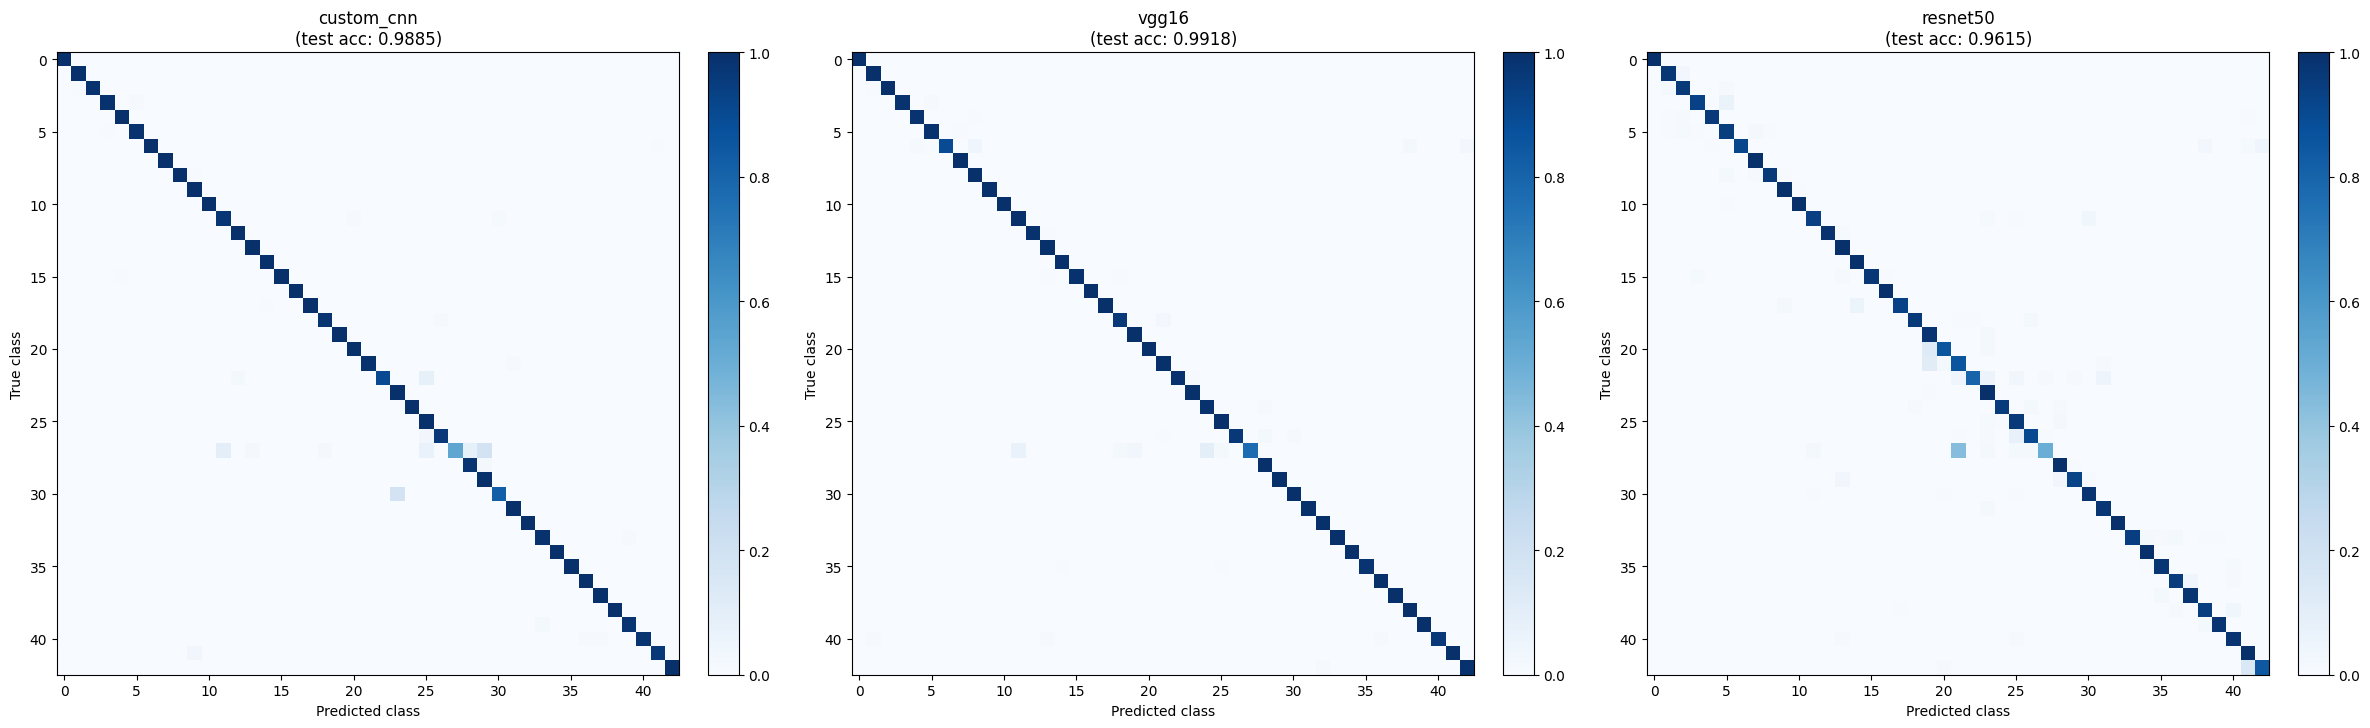

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, (name, pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_true, pred, labels=range(43))

    # Normalize each row so we see per-class error *rates*, not absolute counts.
    # Row-normalization: each row sums to 1, showing where class i's images went.
    cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    # Plot as heatmap. Log scale via small offset so zero-cells are still
    # visible but tiny.
    im = ax.imshow(cm_normalized, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'{name}\n(test acc: {test_results[name]["accuracy"]:.4f})')
    ax.set_xlabel('Predicted class')
    ax.set_ylabel('True class')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(project_root / "report" / "figures" / 'confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [10]:
from sklearn.metrics import classification_report

# Save the full reports to text files for inclusion in the report appendix
REPORT_DIR = project_root / "report" / "tables"

for name, pred in predictions.items():
    report = classification_report(y_true, pred, digits=4, zero_division=0)

    # Save to file
    path = REPORT_DIR / f'classification_report_{name}.txt'
    with open(path, 'w') as f:
        f.write(f"Classification Report — {name}\n")
        f.write("=" * 70 + "\n")
        f.write(report)
    print(f"Saved {path}")

# Now print a summary highlighting weak classes for each model
print("\n" + "=" * 70)
print("WEAKEST CLASSES PER MODEL (by F1 score)")
print("=" * 70)

for name, pred in predictions.items():
    from sklearn.metrics import precision_recall_fscore_support
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, pred, labels=range(43), zero_division=0
    )

    # Get the 5 worst classes by F1
    worst_indices = np.argsort(f1)[:5]
    print(f"\n{name}:")
    print(f"  {'Class':<6} {'Precision':<12} {'Recall':<10} {'F1':<10} {'Support':<10}")
    for idx in worst_indices:
        print(f"  {idx:<6} {precision[idx]:<12.4f} {recall[idx]:<10.4f} "
              f"{f1[idx]:<10.4f} {int(support[idx]):<10}")

Saved C:\Users\Josh\Documents\TrafficSignRecognition\report\tables\classification_report_custom_cnn.txt
Saved C:\Users\Josh\Documents\TrafficSignRecognition\report\tables\classification_report_vgg16.txt
Saved C:\Users\Josh\Documents\TrafficSignRecognition\report\tables\classification_report_resnet50.txt

WEAKEST CLASSES PER MODEL (by F1 score)

custom_cnn:
  Class  Precision    Recall     F1         Support   
  27     0.9143       0.5333     0.6737     60        
  30     0.9609       0.8200     0.8849     150       
  23     0.8475       1.0000     0.9174     150       
  29     0.8654       1.0000     0.9278     90        
  22     0.9908       0.9000     0.9432     120       

vgg16:
  Class  Precision    Recall     F1         Support   
  27     1.0000       0.7667     0.8679     60        
  21     0.8738       1.0000     0.9326     90        
  6      1.0000       0.8933     0.9437     150       
  24     0.9368       0.9889     0.9622     90        
  40     0.9775       0.9667

In [11]:
print("TOP 5 MOST CONFUSED CLASS PAIRS PER MODEL")
print("=" * 70)

for name, pred in predictions.items():
    cm = confusion_matrix(y_true, pred, labels=range(43))

    # Zero the diagonal so we only look at off-diagonal cells
    cm_off_diag = cm.copy()
    np.fill_diagonal(cm_off_diag, 0)

    # Find the top 5 cells by count
    flat_indices = np.argsort(cm_off_diag.flatten())[::-1][:5]
    print(f"\n{name}:")
    print(f"  {'True':<6} {'Predicted':<12} {'Count':<8}")
    for flat_idx in flat_indices:
        true_class = flat_idx // 43
        pred_class = flat_idx % 43
        count = cm_off_diag[true_class, pred_class]
        if count > 0:
            print(f"  {true_class:<6} {pred_class:<12} {count:<8}")

TOP 5 MOST CONFUSED CLASS PAIRS PER MODEL

custom_cnn:
  True   Predicted    Count   
  30     23           27      
  27     29           11      
  22     25           10      
  27     11           6       
  26     25           6       

vgg16:
  True   Predicted    Count   
  18     21           12      
  27     24           6       
  6      8            6       
  12     13           5       
  3      5            5       

resnet50:
  True   Predicted    Count   
  3      5            29      
  27     21           26      
  38     40           25      
  17     14           19      
  1      2            18      


custom_cnn: 27 cases of class 30 (Beware of ice/snow) misclassified as class 23 (Slippery road)
vgg16: 12 cases of class 18 (General caution) misclassified as class 21 (Double curve)
resnet50: 29 cases of class 3 (Speed limit (60km/h)) misclassified as class 5 (Speed limit (80km/h))


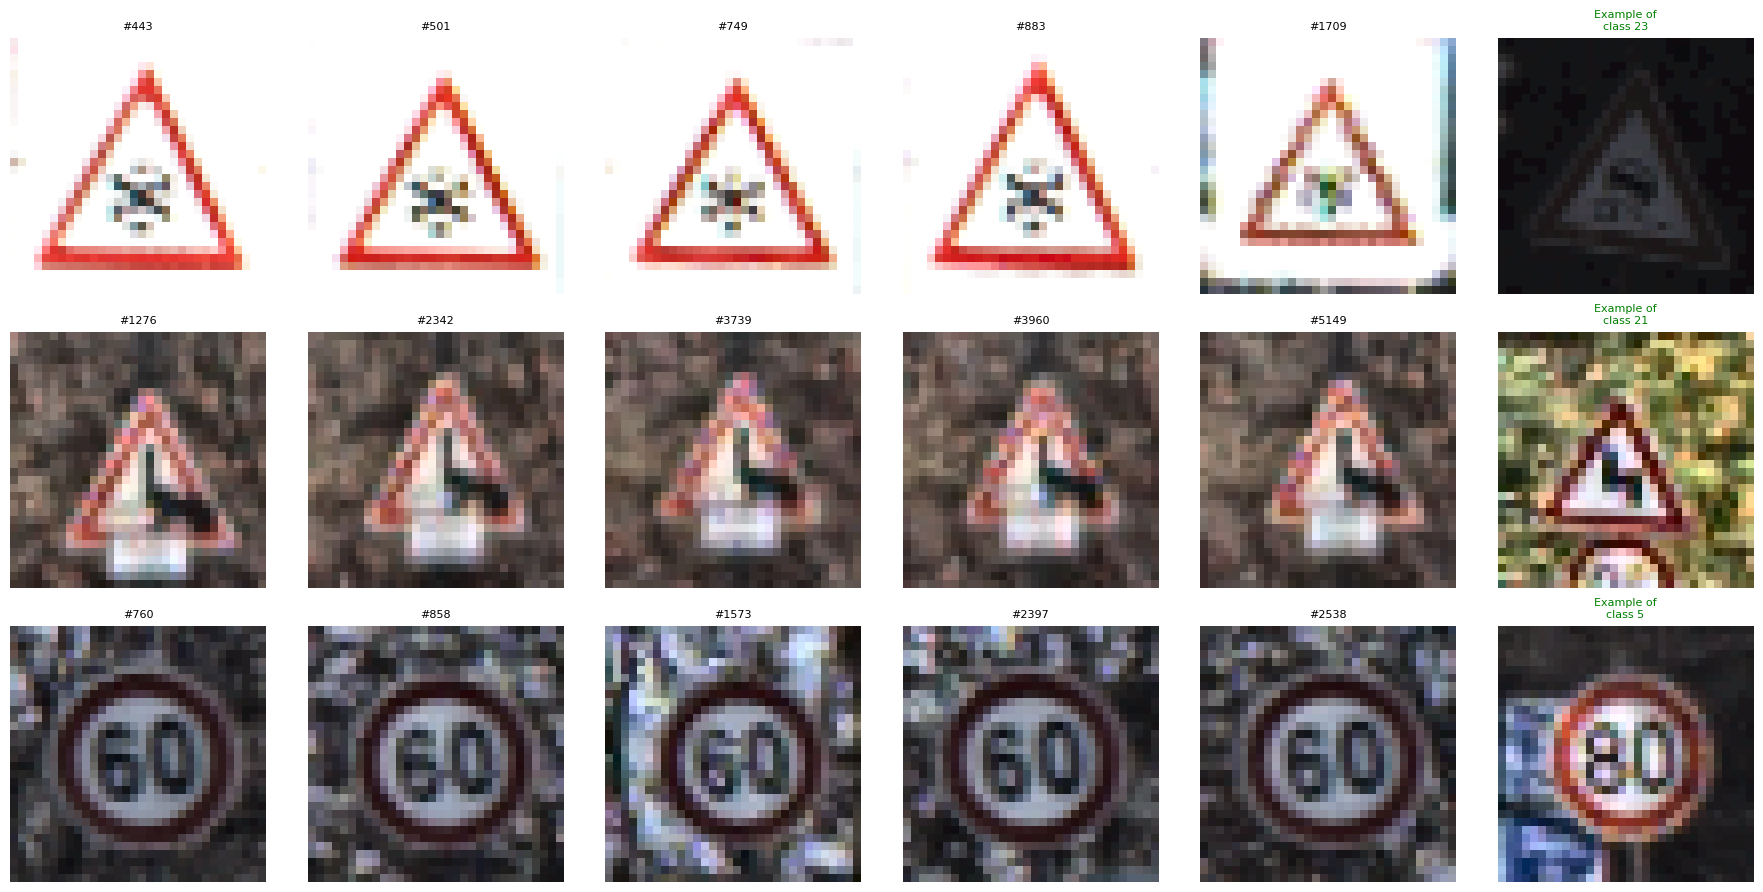

In [12]:
# GTSRB class names — handy for labeling
CLASS_NAMES = {
    0: 'Speed limit (20km/h)', 1: 'Speed limit (30km/h)', 2: 'Speed limit (50km/h)',
    3: 'Speed limit (60km/h)', 4: 'Speed limit (70km/h)', 5: 'Speed limit (80km/h)',
    6: 'End of speed limit (80km/h)', 7: 'Speed limit (100km/h)', 8: 'Speed limit (120km/h)',
    9: 'No passing', 10: 'No passing for vehicles >3.5t', 11: 'Right-of-way at next intersection',
    12: 'Priority road', 13: 'Yield', 14: 'Stop', 15: 'No vehicles',
    16: 'Vehicles >3.5t prohibited', 17: 'No entry', 18: 'General caution',
    19: 'Dangerous curve left', 20: 'Dangerous curve right', 21: 'Double curve',
    22: 'Bumpy road', 23: 'Slippery road', 24: 'Road narrows on the right',
    25: 'Road work', 26: 'Traffic signals', 27: 'Pedestrians',
    28: 'Children crossing', 29: 'Bicycles crossing', 30: 'Beware of ice/snow',
    31: 'Wild animals crossing', 32: 'End of all speed and passing limits',
    33: 'Turn right ahead', 34: 'Turn left ahead', 35: 'Ahead only',
    36: 'Go straight or right', 37: 'Go straight or left', 38: 'Keep right',
    39: 'Keep left', 40: 'Roundabout mandatory', 41: 'End of no passing',
    42: 'End of no passing by vehicles >3.5t'
}

# For each model, find the top confused pair and show example misclassifications
fig, axes = plt.subplots(3, 6, figsize=(18, 9))

top_pairs = {
    'custom_cnn': (30, 23),  # True → Predicted
    'vgg16':      (18, 21),
    'resnet50':   (3, 5),
}

for row, (name, (true_cls, pred_cls)) in enumerate(top_pairs.items()):
    pred = predictions[name]

    # Find indices of test images where true == true_cls and predicted == pred_cls
    mistake_mask = (y_true == true_cls) & (pred == pred_cls)
    mistake_indices = np.where(mistake_mask)[0]

    print(f"{name}: {len(mistake_indices)} cases of class {true_cls} ({CLASS_NAMES[true_cls]}) "
          f"misclassified as class {pred_cls} ({CLASS_NAMES[pred_cls]})")

    # Show first 5 misclassified examples + 1 correct example of the predicted class for comparison
    for col in range(5):
        ax = axes[row, col]
        if col < len(mistake_indices):
            idx = mistake_indices[col]
            ax.imshow(np.clip(X_test[idx], 0, 1))
            ax.set_title(f'#{idx}', fontsize=8)
        ax.axis('off')

    # Last column: a correct example of the *predicted* class for comparison
    ax = axes[row, 5]
    correct_pred_indices = np.where((y_true == pred_cls) & (pred == pred_cls))[0]
    if len(correct_pred_indices) > 0:
        ax.imshow(np.clip(X_test[correct_pred_indices[0]], 0, 1))
        ax.set_title(f'Example of\nclass {pred_cls}', fontsize=8, color='green')
    ax.axis('off')

    # Row label
    axes[row, 0].set_ylabel(f'{name}\nTrue: {true_cls} ({CLASS_NAMES[true_cls][:20]})\n'
                            f'→ pred: {pred_cls} ({CLASS_NAMES[pred_cls][:20]})',
                            fontsize=8, rotation=0, ha='right', va='center', labelpad=5)

plt.tight_layout()
plt.savefig(project_root / "report" / "figures" / 'misclassified_examples.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [13]:
import numpy as np

PREDS_DIR = project_root / "report" / "predictions"
PREDS_DIR.mkdir(parents=True, exist_ok=True)

np.savez(PREDS_DIR / 'all_predictions.npz',
         y_true=y_true,
         custom_cnn=predictions['custom_cnn'],
         vgg16=predictions['vgg16'],
         resnet50=predictions['resnet50'])

print(f"Saved predictions to {PREDS_DIR / 'all_predictions.npz'}")
print(f"To reload later: np.load('{PREDS_DIR / 'all_predictions.npz'}')")

Saved predictions to C:\Users\Josh\Documents\TrafficSignRecognition\report\predictions\all_predictions.npz
To reload later: np.load('C:\Users\Josh\Documents\TrafficSignRecognition\report\predictions\all_predictions.npz')
